## Alignment - MNIST example GEODESICS

Goals:

* Show alignment methods on real learned data
* train vaes and construct manifolds
* plot manifolds with data (three classes)
* of course use geodesics:)

Hypothesis: 
* If latent distributions are non-symmetric AND geometry is non-symmetric, then GW can find a unique minimizer (for all classes iff the classes have inter distinguishable distributions) and in theory align the classes very good (if the models are trained so the classes can be expected to be well seperated)

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import matplotlib.pyplot as plt
import torch
import pandas as pd

from sklearn.decomposition import PCA
from scipy.optimize import minimize
from scipy.stats import vonmises_fisher
from scipy.spatial.distance import cdist, pdist, squareform
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


from colors import color_segment
from supervised_vae import SupervisedVAE
from train_two_vaes import train_two_vaes
from plot_vaes import plot_vae_latent_alignment
from utils_GW import *
from geodesics import *

blue_pink = color_segment()

Setup:

1. `train_two_vaes.py` splits MNIST dataset once (should happen in training script) into four sets {train, val, align, test}
2. `mnist_geodesics.ipynb` notebook loads saved splits and (trains) models
    * train both VAE A and VAE B on the same train / val split but using different seeds
3. choose 3 anchor images per class from the align split using a random seed
4. compute 36 pairwise (geodesic) distances per domain (A and B) use the linear energy approximation
5. run GW on the two 9x9 distance matrices
    * finding a global map from B to A: using an affine baseline with a fixed parameterization consisting of a rotation and translation
    * finding a global map from B to A: but use a neural network to learn the parametrization of the map
6. validate on unseen test images:
    * apply the map to the latent space B (getting aligned B) and overlaying with latent space A : these should fit (use same PCA mapping)
    * or advanced validate: sample from latent space B (an image neither trained, validated nor used for alignment) and decode in latent space A : the class should be the same for the two + the image should display an unambiguous digit.

In [3]:
# # train new models and save checkpoints / split artifacts
# train_out = train_two_vaes(
#     device="cpu",                  
#     epochs=50,
#     batch_size=128,
#     latent_dim=8,
#     lr=1e-3,
#     prefix="checkpoints/mnist_same_3classes",
#     num_classes=3,
#     digits=[0, 1, 2],             
#     seedA=0,
#     seedB=12,
#     split_seed=123,
#     train_frac=0.7,
#     val_frac=0.1,
#     align_frac=0.1,
#     test_frac=0.1,
# )

In [4]:
# --- config ---
latent_dim = 8
num_classes = 3
prefix = "checkpoints/mnist_same_3classes"  # must match training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- load models ---
vaeA = SupervisedVAE(latent_dim=latent_dim, num_classes=num_classes)
vaeB = SupervisedVAE(latent_dim=latent_dim, num_classes=num_classes)

vaeA.load_state_dict(torch.load(f"{prefix}_vaeA.pt", map_location=device))
vaeB.load_state_dict(torch.load(f"{prefix}_vaeB.pt", map_location=device))

vaeA.to(device).eval()
vaeB.to(device).eval()

# --- load data splits (need align + test) ---
A_align = torch.load(f"{prefix}_A_align.pt", map_location="cpu")
B_align = torch.load(f"{prefix}_B_align.pt", map_location="cpu")

A_test = torch.load(f"{prefix}_A_test.pt", map_location="cpu")
B_test = torch.load(f"{prefix}_B_test.pt", map_location="cpu")

# --- extract latents (with labels) ---
zA_align = A_align["z"]
zB_align = B_align["z"]
y_align  = A_align["y"]

zA_test = A_test["z"]
zB_test = B_test["z"]
y_test  = A_test["y"]

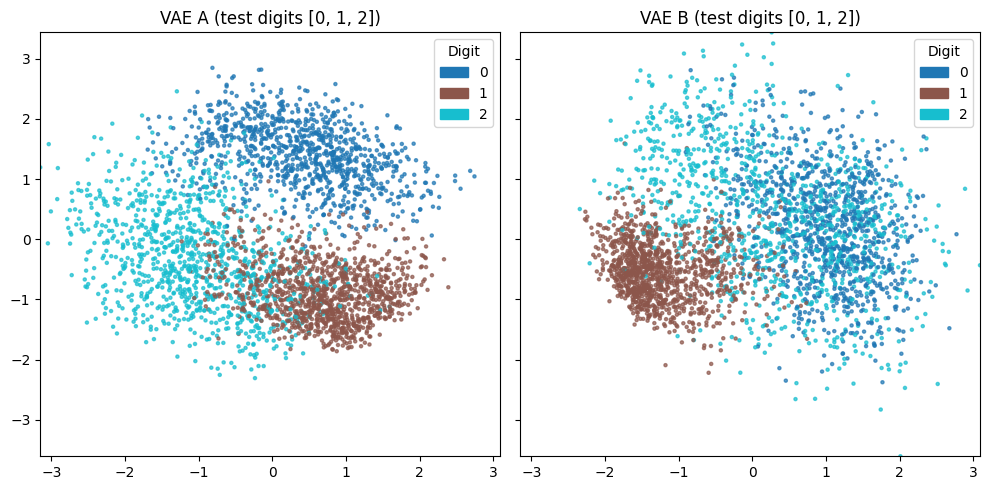

In [5]:
plot_vae_latent_alignment(
    checkpoint_prefix="checkpoints/mnist_same_3classes",
    data_root="data/",
    latent_dim=8,
    device="cpu",
)

In [6]:
# choose class-balanced but independently sampled anchors in the two domains
samples_per_class = 20

anchor_indices_A = sample_anchor_indices_by_class(
    y_align,
    samples_per_class=samples_per_class,
    seed=0,
    sort_indices=True,
)

anchor_indices_B = sample_anchor_indices_by_class(
    y_align,
    samples_per_class=samples_per_class,
    seed=1,
    sort_indices=True,
)

anchor_labels_A = validate_anchor_indices(
    anchor_indices_A,
    y_align,
    samples_per_class=samples_per_class,
)

anchor_labels_B = validate_anchor_indices(
    anchor_indices_B,
    y_align,
    samples_per_class=samples_per_class,
)

print("anchor indices A:", anchor_indices_A.tolist())
print("anchor indices B:", anchor_indices_B.tolist())
print("anchor labels A: ", anchor_labels_A.tolist())
print("anchor labels B: ", anchor_labels_B.tolist())

xA_anchor = A_align["x"][anchor_indices_A]
xB_anchor = B_align["x"][anchor_indices_B]

zA_anchor = zA_align[anchor_indices_A]
zB_anchor = zB_align[anchor_indices_B]

yA_anchor = y_align[anchor_indices_A]
yB_anchor = y_align[anchor_indices_B]

anchor indices A: [59, 64, 81, 83, 104, 108, 121, 165, 171, 224, 269, 290, 291, 330, 365, 447, 560, 662, 668, 686, 707, 718, 723, 755, 832, 841, 871, 898, 904, 924, 928, 931, 932, 939, 966, 1026, 1035, 1082, 1119, 1138, 1154, 1156, 1165, 1205, 1227, 1242, 1254, 1282, 1285, 1346, 1366, 1378, 1425, 1451, 1467, 1482, 1584, 1595, 1760, 1772]
anchor indices B: [13, 83, 121, 151, 173, 247, 261, 273, 292, 350, 373, 377, 416, 417, 432, 443, 457, 484, 488, 537, 584, 587, 597, 627, 649, 661, 708, 747, 752, 799, 874, 886, 905, 911, 934, 941, 1024, 1083, 1093, 1158, 1168, 1188, 1215, 1218, 1260, 1315, 1320, 1347, 1417, 1433, 1515, 1520, 1552, 1619, 1674, 1675, 1676, 1677, 1727, 1786]
anchor labels A:  [1, 0, 1, 0, 1, 2, 0, 2, 1, 0, 2, 0, 1, 1, 1, 1, 1, 2, 0, 2, 0, 2, 2, 0, 2, 1, 2, 0, 2, 0, 1, 0, 2, 1, 0, 2, 2, 1, 1, 1, 1, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 0, 2, 1, 2, 1, 0, 1, 2, 0]
anchor labels B:  [1, 0, 0, 1, 2, 0, 1, 2, 0, 0, 1, 2, 1, 0, 1, 1, 1, 0, 1, 2, 1, 2, 1, 0, 2, 0, 2, 2, 2, 1, 1, 1, 0, 0,

In [7]:
# # choose 9 fixed point samples common to both domains
# anchor_seed = 0
# samples_per_class = 20

# anchor_indices = sample_anchor_indices_by_class(
#     y_align,
#     samples_per_class=samples_per_class,
#     seed=anchor_seed,
#     sort_indices=True,
# )

# anchor_labels = validate_anchor_indices(
#     anchor_indices,
#     y_align,
#     samples_per_class=samples_per_class,
# )

# # --- print anchor info and extract anchor latents ---
# print("anchor indices:", anchor_indices.tolist()) # the indices in A and B domain are the same since no shuffle
# print("anchor labels: ", anchor_labels.tolist())

# xA_anchor = A_align["x"][anchor_indices]
# xB_anchor = B_align["x"][anchor_indices]

# zA_anchor = zA_align[anchor_indices]
# zB_anchor = zB_align[anchor_indices]
# y_anchor  = y_align[anchor_indices]

In [8]:
# plt.figure(figsize=(15, 5))
# for i in range(len(anchor_indices)):
#     plt.subplot(3, 3, i + 1)
#     plt.imshow(xA_anchor[i, 0], cmap="gray")
#     plt.title(f"label={int(y_anchor[i])}")
#     plt.axis("off")
# plt.tight_layout()
# plt.show()

In [9]:
# compute geodesics:
num_segments = 10

D_A = pairwise_geodesic_distances(
    vaeA,
    zA_anchor,
    num_segments=num_segments,
    device=device,
)

D_B = pairwise_geodesic_distances( # this uses the decoder of the VAE B...
    vaeB,
    zB_anchor,
    num_segments=num_segments,
    device=device,
)

D_A_euclid = squareform(pdist(zA_anchor.numpy(), metric="euclidean"))
D_B_euclid = squareform(pdist(zB_anchor.numpy(), metric="euclidean"))

print("D_A shape:", D_A.shape)
print("D_B shape:", D_B.shape)
print("expected number of pairs:", number_of_pairwise_distances(len(zA_anchor)))

D_A shape: (60, 60)
D_B shape: (60, 60)
expected number of pairs: 1770


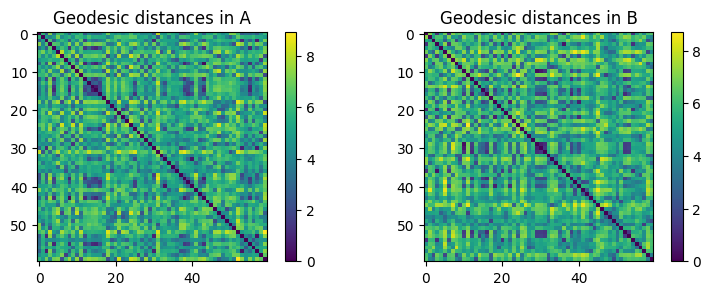

In [10]:
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.imshow(D_A, cmap="viridis")
plt.title("Geodesic distances in A")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(D_B, cmap="viridis")
plt.title("Geodesic distances in B")
plt.colorbar()

plt.tight_layout()
plt.show()

(this is not sorted anymore by the same pairs, so pretty useless for geodesic comparison...)

In [11]:
def within_cross_means(D, labels):
    within, cross = [], []
    labels = np.asarray(labels)

    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            if labels[i] == labels[j]:
                within.append(D[i, j])
            else:
                cross.append(D[i, j])

    return np.mean(within), np.mean(cross), np.array(within), np.array(cross)

A_within_geo, A_cross_geo, A_within_geo_all, A_cross_geo_all = within_cross_means(D_A, yA_anchor.numpy())
A_within_euc, A_cross_euc, A_within_euc_all, A_cross_euc_all = within_cross_means(D_A_euclid, yA_anchor.numpy())

print("A geodesic  mean within:", A_within_geo, "mean cross:", A_cross_geo)
print("A euclidean mean within:", A_within_euc, "mean cross:", A_cross_euc)

B_within_geo, B_cross_geo, _, _ = within_cross_means(D_B, yB_anchor.numpy())
B_within_euc, B_cross_euc, _, _ = within_cross_means(D_B_euclid, yB_anchor.numpy())

print("B geodesic  mean within:", B_within_geo, "mean cross:", B_cross_geo)
print("B euclidean mean within:", B_within_euc, "mean cross:", B_cross_euc)

print("A geodesic separation ratio :", A_cross_geo / A_within_geo)
print("A euclidean separation ratio:", A_cross_euc / A_within_euc)

print("B geodesic separation ratio :", B_cross_geo / B_within_geo)
print("B euclidean separation ratio:", B_cross_euc / B_within_euc)

A geodesic  mean within: 3.9744213 mean cross: 5.815106
A euclidean mean within: 3.480636332868755 mean cross: 4.2301590614691555
B geodesic  mean within: 4.111997 mean cross: 5.7361555
B euclidean mean within: 3.442542119249728 mean cross: 4.172313146931538
A geodesic separation ratio : 1.4631327
A euclidean separation ratio: 1.2153407184549616
B geodesic separation ratio : 1.3949804
B euclidean separation ratio: 1.2119860853992566


The ratio of means could hint that the geodesic distances is a better estimate for seperating between inter- and intra distances. This could help GW.

**Solving for a global map using GW:**

In [12]:
# coupling from the anchor distance matrices:
P, gw_loss = solve_gw_coupling(
    D_A,
    D_B,
    epsilon=0.02,
    threshold=1e-6,
)

print("GW loss:", gw_loss)
print("Coupling shape:", P.shape)

GW loss: 0.06559466115582792
Coupling shape: (60, 60)


In [13]:
P

array([[0.00031491, 0.00019584, 0.00022769, ..., 0.00028643, 0.00018371,
        0.00023871],
       [0.00025393, 0.00032997, 0.00032133, ..., 0.00027328, 0.00033521,
        0.00031898],
       [0.00031714, 0.00018405, 0.00022066, ..., 0.00028434, 0.00017124,
        0.00023388],
       ...,
       [0.00031533, 0.00019828, 0.00022586, ..., 0.00028859, 0.00018664,
        0.00023367],
       [0.00029236, 0.0002527 , 0.00026517, ..., 0.000288  , 0.00024573,
        0.000268  ],
       [0.00020502, 0.0004314 , 0.0003639 , ..., 0.00024583, 0.00046286,
        0.00034388]], shape=(60, 60))

##### **Global map: rotation + translation fixed**

mapping from B-space into A-space: $T_B(z) = zR + t$

Assuming the global map is an orthogonal map $R$

($W$ can "cheat" and reduce loss drastically while destroying structure, making the mapping only linear)

In [20]:
# global map between the anchor points
R, t = fit_orthogonal_map_from_coupling(
    zA_anchor.numpy(),
    zB_anchor.numpy(),
    P
)

print("R shape:", R.shape)
print("t shape:", t.shape)

R shape: (8, 8)
t shape: (8,)


In [21]:
P

array([[0.00031491, 0.00019584, 0.00022769, ..., 0.00028643, 0.00018371,
        0.00023871],
       [0.00025393, 0.00032997, 0.00032133, ..., 0.00027328, 0.00033521,
        0.00031898],
       [0.00031714, 0.00018405, 0.00022066, ..., 0.00028434, 0.00017124,
        0.00023388],
       ...,
       [0.00031533, 0.00019828, 0.00022586, ..., 0.00028859, 0.00018664,
        0.00023367],
       [0.00029236, 0.0002527 , 0.00026517, ..., 0.000288  , 0.00024573,
        0.000268  ],
       [0.00020502, 0.0004314 , 0.0003639 , ..., 0.00024583, 0.00046286,
        0.00034388]], shape=(60, 60))

In [15]:
# global map between the anchor points using W and the fit affine function (using linalg solve, gets a linear map)
W, t_W = fit_affine_map_from_coupling(
    zA_anchor.numpy(),
    zB_anchor.numpy(),
    P
)

print("W shape:", W.shape)
print("t_W shape:", t_W.shape)

W shape: (8, 8)
t_W shape: (8,)


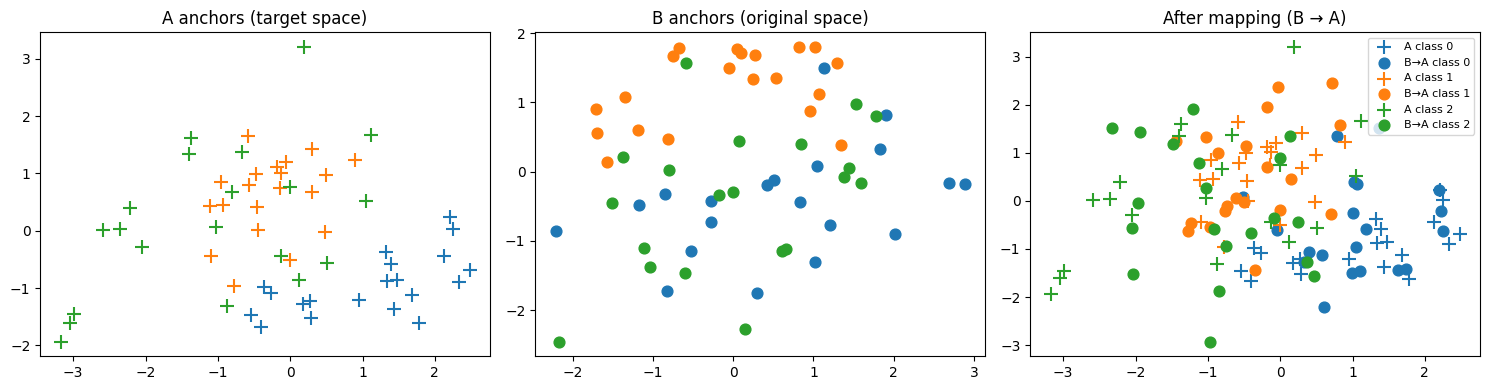

In [16]:
# --- data ---
zA_np = zA_anchor.numpy()
zB_np = zB_anchor.numpy()
zB_mapped = zB_np @ R + t
labels_A = yA_anchor.numpy()
labels_B = yB_anchor.numpy()

# --- PCA (shared space) ---
Z_all = np.vstack([zA_np, zB_np, zB_mapped])
pca = PCA(n_components=2)
Z2 = pca.fit_transform(Z_all)

n = len(zA_np)
A2  = Z2[:n]
B2  = Z2[n:2*n]
Bm2 = Z2[2*n:]

# --- color setup (discrete per digit) ---
unique_labels = np.unique(np.concatenate([labels_A, labels_B]))
colors = plt.cm.tab10(unique_labels)

color_map = {k: plt.cm.tab10(k) for k in unique_labels}

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) A anchors
for k in unique_labels:
    idx = labels_A == k
    axes[0].scatter(A2[idx, 0], A2[idx, 1],
                    color=color_map[k],
                    marker="+", s=100)
axes[0].set_title("A anchors (target space)")

# 2) B anchors
for k in unique_labels:
    idx = labels_B == k
    axes[1].scatter(B2[idx, 0], B2[idx, 1],
                    color=color_map[k],
                    marker="o", s=60)
axes[1].set_title("B anchors (original space)")

# 3) Overlay: A (+) and mapped B (o)
for k in unique_labels:
    idxA = labels_A == k
    idxB = labels_B == k
    axes[2].scatter(A2[idxA, 0], A2[idxA, 1],
                    color=color_map[k],
                    marker="+", s=100, label=f"A class {k}")
    axes[2].scatter(Bm2[idxB, 0], Bm2[idxB, 1],
                    color=color_map[k],
                    marker="o", s=60, label=f"B→A class {k}")

axes[2].set_title("After mapping (B → A)")

# --- clean legend (unique entries only) ---
handles, labels_leg = axes[2].get_legend_handles_labels()
by_label = dict(zip(labels_leg, handles))
axes[2].legend(by_label.values(), by_label.keys(), fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
# anchor_error_before = np.linalg.norm(zA_anchor - zB_anchor, axis=1)
# anchor_error_after_nn = np.linalg.norm(zA_anchor - zB_mapped, axis=1)

# print("Mean anchor error zB vs zA:", anchor_error_before.mean())
# print("Mean anchor error after (zA vs zB_mapped):", anchor_error_after_nn.mean())

In [18]:
print("rank(R):", np.linalg.matrix_rank(R))
print("singular values of R:", np.linalg.svd(R, compute_uv=False))

Zc = zB_mapped - zB_mapped.mean(axis=0, keepdims=True)
print("rank(mapped anchors):", np.linalg.matrix_rank(Zc))
print("eigenvalues of mapped covariance:", np.linalg.eigvalsh(np.cov(Zc.T)))

rank(R): 8
singular values of R: [1. 1. 1. 1. 1. 1. 1. 1.]
rank(mapped anchors): 8
eigenvalues of mapped covariance: [0.51409052 0.67933742 0.73163742 0.82174157 1.03249644 1.14158618
 1.42418714 1.82034672]


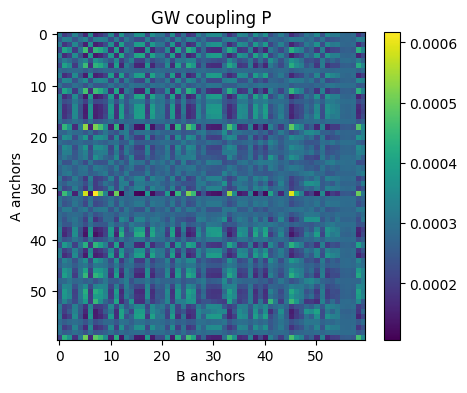

In [19]:
plt.figure(figsize=(5, 4))
plt.imshow(P, cmap="viridis")
plt.colorbar()
plt.title("GW coupling P")
plt.xlabel("B anchors")
plt.ylabel("A anchors")
plt.show()

concluding:
* geometry (exact image to image match) is not preserved exactly with an affine coupling as map
* classes are roughly mapped in the right regions

#### **Global map: NN learned**

In [1]:
residual_map = train_residual_map_from_coupling(
    X_src=zA_anchor.numpy(),
    X_tgt=zB_anchor.numpy(),
    P=P,
    hidden_dim=32,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=50,
    lambda_disp=0,
    lambda_geom=1e-1,
    device=device,
    verbose=True,
    identity_init=True,
    geom_metric="geodesic",
    model_src_geom=vaeA,   # VAE for A-space
    model_tgt_geom=vaeB,   # VAE for B-space
    num_segments=3,
)

NameError: name 'train_residual_map_from_coupling' is not defined

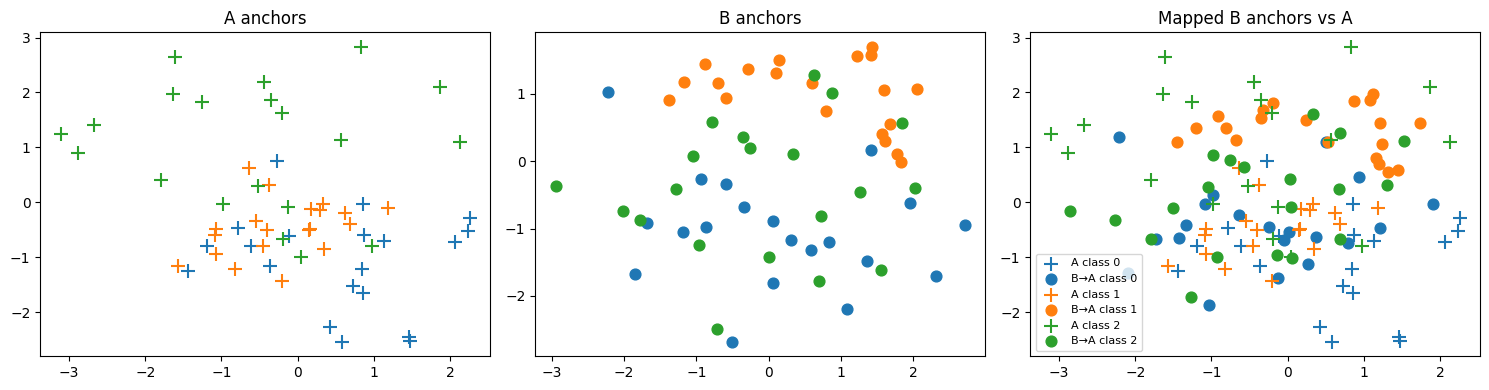

In [51]:
# apply the learned map to the B anchors
zB_anchor_mapped_nn = apply_residual_map(
    residual_map,
    zB_anchor.numpy(),
    device=device,
)

# --- plot anchor alignment ---
zA_np = zA_anchor.numpy()
zB_np = zB_anchor.numpy()
labels_A = yA_anchor.numpy()
labels_B = yB_anchor.numpy()

Z_all = np.vstack([zA_np, zB_np, zB_anchor_mapped_nn])
pca = PCA(n_components=2)
Z2 = pca.fit_transform(Z_all)

n = len(zA_np)
A2  = Z2[:n]
B2  = Z2[n:2*n]
Bm2 = Z2[2*n:]

unique_labels = np.unique(np.concatenate([labels_A, labels_B]))
color_map = {k: plt.cm.tab10(k) for k in unique_labels}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for k in unique_labels:
    idx = labels_A == k
    axes[0].scatter(A2[idx, 0], A2[idx, 1], color=color_map[k], marker="+", s=100)
axes[0].set_title("A anchors")

for k in unique_labels:
    idx = labels_B == k
    axes[1].scatter(B2[idx, 0], B2[idx, 1], color=color_map[k], marker="o", s=60)
axes[1].set_title("B anchors")

for k in unique_labels:
    idxA = labels_A == k
    idxB = labels_B == k
    axes[2].scatter(
        A2[idxA, 0], A2[idxA, 1],
        color=color_map[k],
        marker="+", s=100,
        label=f"A class {k}"
    )
    axes[2].scatter(
        Bm2[idxB, 0], Bm2[idxB, 1],
        color=color_map[k],
        marker="o", s=60,
        label=f"B→A class {k}"
    )
axes[2].set_title("Mapped B anchors vs A")

# --- clean legend (unique entries only) ---
handles, labels_leg = axes[2].get_legend_handles_labels()
by_label = dict(zip(labels_leg, handles))
axes[2].legend(by_label.values(), by_label.keys(), fontsize=8)

plt.tight_layout()
plt.show()

In [21]:
# anchor_error_before = np.linalg.norm(zA_anchor.numpy() - zB_anchor.numpy(), axis=1)
# anchor_error_after_nn = np.linalg.norm(zA_anchor.numpy() - zB_anchor_mapped_nn, axis=1)

# print("Mean anchor error zB vs zA:", anchor_error_before.mean())
# print("Mean anchor error after NN (zA vs zB_mapped):", anchor_error_after_nn.mean())

#### **Try out Flow learned map**



In [29]:
flow_map = train_flow_map_from_coupling(
    X_src=zA_anchor.numpy(),
    X_tgt=zB_anchor.numpy(),
    P=P,
    transforms=4,
    hidden_features=(64, 64),
    bins=8,
    lr=1e-3,
    weight_decay=1e-5,
    epochs=2000,
    device=device,
    verbose=True,
    patience=100,
    min_delta=1e-3,
    restore_best=True,
)
# need some early stopping.

[ZukoFlowMap epoch    1] fit=16.676056 best=16.676056 wait=0
[ZukoFlowMap epoch  200] fit=7.775383 best=7.776277 wait=28
[ZukoFlowMap epoch  400] fit=7.772705 best=7.773139 wait=93
[ZukoFlowMap early stop] epoch=407 best_fit=7.773139


In [23]:
zB_test_mapped_flow = apply_flow_map(
    flow_map,
    zB_test.numpy(),
    device=device,
)

test_error_before = np.linalg.norm(zA_test.numpy() - zB_test.numpy(), axis=1)
test_error_after_flow = np.linalg.norm(zA_test.numpy() - zB_test_mapped_flow, axis=1)

print("Mean test error before (zA vs zB):", test_error_before.mean())
print("Mean test error after flow (zA vs zB_mapped):", test_error_after_flow.mean())

Mean test error before (zA vs zB): 4.092877
Mean test error after flow (zA vs zB_mapped): 2.7018392


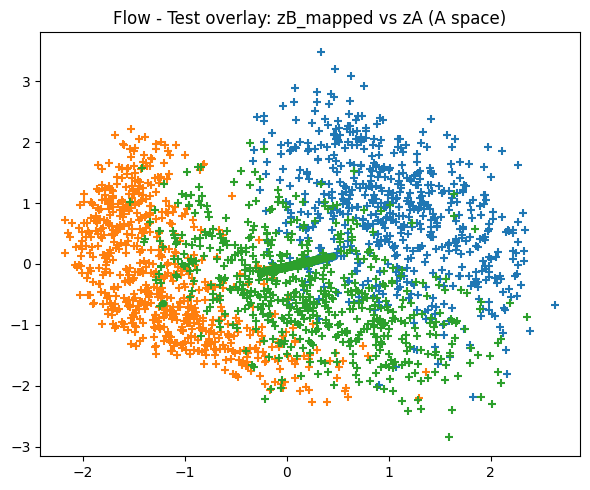

In [24]:
Z_all = np.vstack([zA_test.numpy(), zB_test_mapped_flow])
pca = PCA(n_components=2)
Z2 = pca.fit_transform(Z_all)

n = len(zA_test)
A2  = Z2[:n]
Bm2 = Z2[n:]

labels_test = y_test.numpy()
unique_labels = np.unique(labels_test)
color_map = {k: plt.cm.tab10(k) for k in unique_labels}

plt.figure(figsize=(6, 5))
for k in unique_labels:
    idx = labels_test == k
    plt.scatter(A2[idx, 0], A2[idx, 1], color=color_map[k], marker="+", s=40)
    plt.scatter(Bm2[idx, 0], Bm2[idx, 1], color=color_map[k], marker="o", s=20)

plt.title("Flow - Test overlay: zB_mapped vs zA (A space)")
plt.tight_layout()
plt.show()

#### *Evaluated residual map on the test set:*

Mean test error before (zA vs zB): 4.092877
Mean test error after NN (zA vs zB_mapped): 3.965388


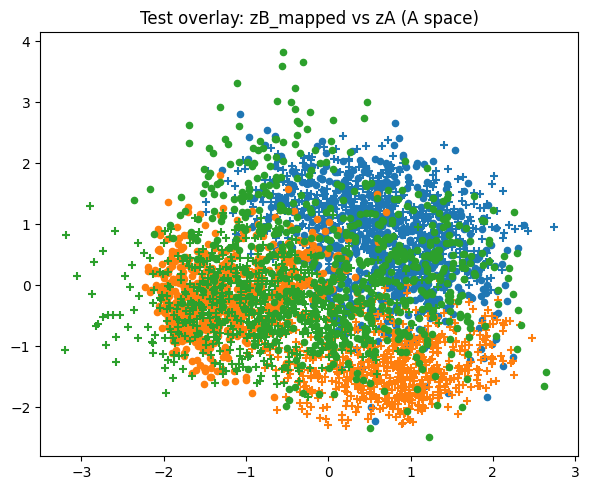

In [52]:
zB_test_mapped_nn = apply_residual_map(
    residual_map,
    zB_test.numpy(),
    device=device,
)

# compute test errors before and after mapping:
test_error_before = np.linalg.norm(zA_test.numpy() - zB_test.numpy(), axis=1)
test_error_after_nn = np.linalg.norm(zA_test.numpy() - zB_test_mapped_nn, axis=1)

print("Mean test error before (zA vs zB):", test_error_before.mean())
print("Mean test error after NN (zA vs zB_mapped):", test_error_after_nn.mean())

# plot test overlay:
Z_all = np.vstack([zA_test.numpy(), zB_test_mapped_nn])
pca = PCA(n_components=2)
Z2 = pca.fit_transform(Z_all)

n = len(zA_test)
A2  = Z2[:n]
Bm2 = Z2[n:]

labels_test = y_test.numpy()
unique_labels = np.unique(labels_test)
color_map = {k: plt.cm.tab10(k) for k in unique_labels}

plt.figure(figsize=(6, 5))
for k in unique_labels:
    idx = labels_test == k
    plt.scatter(A2[idx, 0], A2[idx, 1], color=color_map[k], marker="+", s=40)
    plt.scatter(Bm2[idx, 0], Bm2[idx, 1], color=color_map[k], marker="o", s=20)

plt.title("Test overlay: zB_mapped vs zA (A space)")
plt.tight_layout()
plt.show()

**Validating on test set: Sample in B, map, decode in A**

1. Pick an image in B
2. Map it to A
3. Decode it
4. Plot in A space:
    * where the image is in the latent space
    * the image displaying the digit

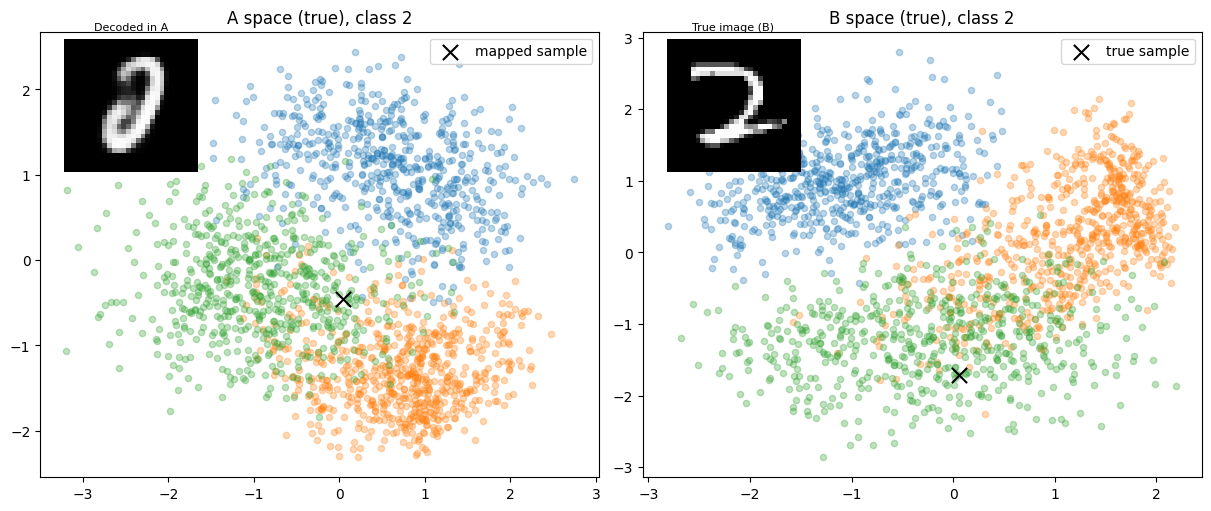

In [53]:


# --- PCA for A-space ---
Z_all_A = np.vstack([zA_test.numpy(), zB_test_mapped_nn])
pca_A = PCA(n_components=2)
Z2_A = pca_A.fit_transform(Z_all_A)

n = len(zA_test)
A2  = Z2_A[:n]
Bm2 = Z2_A[n:]

# --- PCA for B-space ---
Z_B = zB_test.numpy()
pca_B = PCA(n_components=2)
B2 = pca_B.fit_transform(Z_B)

labels = y_test.numpy()
unique_labels = np.unique(labels)
color_map = {k: plt.cm.tab10(k) for k in unique_labels}

# --- choose ONE test sample ---
idx = 20#34#881
zB_sample = zB_test[idx:idx+1]
label_sample = y_test[idx].item()

# IMPORTANT: get TRUE image from dataset
xB_sample = B_test["x"][idx:idx+1]   # <-- THIS is the real image

# map it
zA_sample = apply_residual_map(residual_map, zB_sample.numpy(), device=device)
zA_sample = torch.tensor(zA_sample, dtype=torch.float32)

# project sample
zA_sample_2d = pca_A.transform(zA_sample.numpy())[0]
zB_sample_2d = pca_B.transform(zB_sample.numpy())[0]

# decode mapped sample in A (optional comparison)
with torch.no_grad():
    xA_decoded = torch.sigmoid(vaeA.decode(zA_sample.to(device))).cpu()

# --- plotting ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# ===================== LEFT: A-space =====================
ax = axes[0]

# only TRUE A test points
for k in unique_labels:
    idx_k = labels == k
    ax.scatter(A2[idx_k, 0], A2[idx_k, 1],
               color=color_map[k], marker="o", s=20, alpha=0.3)

# mapped sample
ax.scatter(zA_sample_2d[0], zA_sample_2d[1],
           color="black", marker="x", s=120, label="mapped sample")

ax.set_title(f"A space (true), class {label_sample}")
ax.legend()

# inset: decoded in A
axins = inset_axes(ax, width="30%", height="30%", loc="upper left")
axins.imshow(xA_decoded[0, 0], cmap="gray")
axins.set_title("Decoded in A", fontsize=8)
axins.axis("off")

# ===================== RIGHT: B-space =====================
ax = axes[1]

for k in unique_labels:
    idx_k = labels == k
    ax.scatter(B2[idx_k, 0], B2[idx_k, 1],
               color=color_map[k], marker="o", s=20, alpha=0.3)

ax.scatter(zB_sample_2d[0], zB_sample_2d[1],
           color="black", marker="x", s=120, label="true sample")

ax.set_title(f"B space (true), class {label_sample}")
ax.legend()

# inset: TRUE image from B dataset
axins = inset_axes(ax, width="30%", height="30%", loc="upper left")
axins.imshow(xB_sample[0, 0], cmap="gray")
axins.set_title("True image (B)", fontsize=8)
axins.axis("off")

plt.show()

The spaces seem to be very much aligned (at least in 2D), the map might be trivial...

The map might map too strict to zA so that the classes are pulled together.

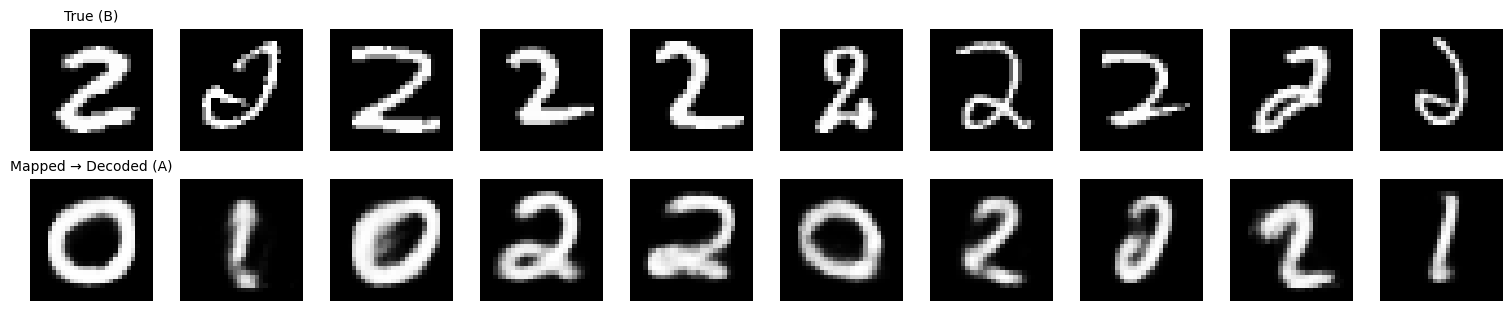

In [54]:
# looking only at one class and decoding images after mapping
target_class = 2
num_samples = 10

# --- get indices of chosen class ---
mask = (y_test == target_class)
indices = torch.where(mask)[0]

# take first 10
selected_idx = indices[:num_samples]

# --- collect images ---
true_images = []
decoded_images = []

for idx in selected_idx:
    zB_sample = zB_test[idx:idx+1]

    # true image from B
    xB_sample = B_test["x"][idx:idx+1]

    # map to A
    zA_sample = apply_residual_map(
        residual_map,
        zB_sample.numpy(),
        device=device,
    )
    zA_sample = torch.tensor(zA_sample, dtype=torch.float32)

    # decode in A
    with torch.no_grad():
        xA_decoded = torch.sigmoid(
            vaeA.decode(zA_sample.to(device))
        ).cpu()

    true_images.append(xB_sample[0, 0])
    decoded_images.append(xA_decoded[0, 0])

# --- plot ---
fig, axes = plt.subplots(2, num_samples, figsize=(num_samples*1.5, 3), constrained_layout=True)

for i in range(num_samples):
    # top row: true images
    axes[0, i].imshow(true_images[i], cmap="gray")
    axes[0, i].axis("off")

    # bottom row: decoded images
    axes[1, i].imshow(decoded_images[i], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_title("True (B)", fontsize=10)
axes[1, 0].set_title("Mapped → Decoded (A)", fontsize=10)

plt.show()